In [14]:
!pip install faiss-cpu


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 112.3 MB/s eta 0:00:00


In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
import faiss


In [16]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

train_set = datasets.STL10("./data", split="unlabeled", download=True, transform=transform)
test_set = datasets.STL10("./data", split="test", download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=32, shuffle=False)


100%|██████████| 2.64G/2.64G [01:14<00:00, 35.4MB/s]


In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"

backbone = models.resnet50(pretrained=True)
backbone = nn.Sequential(*list(backbone.children())[:-1])  # remove FC
backbone = backbone.to(device).eval()


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 76.8MB/s]


In [19]:
subset = torch.utils.data.Subset(train_set, range(5000))  # use first 500 images
train_loader = torch.utils.data.DataLoader(subset, batch_size=32, shuffle=True)


In [21]:
memory_bank = []

with torch.no_grad():
    for x, _ in train_loader:
        x = x.to(device)
        f = backbone(x).squeeze()      # shape: (batch, 2048)
        memory_bank.append(f.cpu())

memory_bank = torch.cat(memory_bank, dim=0).numpy()
index = faiss.IndexFlatL2(memory_bank.shape[1])
index.add(memory_bank)


In [22]:
def anomaly_score(x):
    backbone.eval()
    with torch.no_grad():
        f = backbone(x.to(device)).squeeze().cpu().numpy()
    f = np.expand_dims(f, axis=0)
    D, _ = index.search(f, 1)
    return D[0][0]


In [23]:
scores = []
labels = []

for x, y in test_loader:
    for i in range(x.size(0)):
        score = anomaly_score(x[i:i+1])
        scores.append(score)

        # STL10: class 0 = airplane (normal), others anomaly
        labels.append(0 if y[i].item() == 0 else 1)


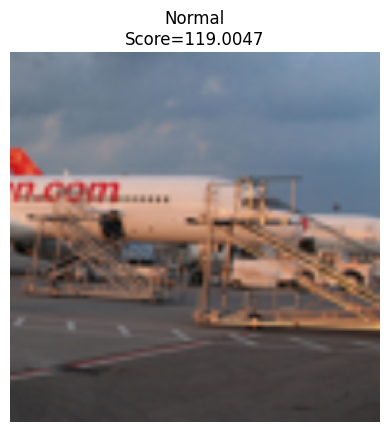

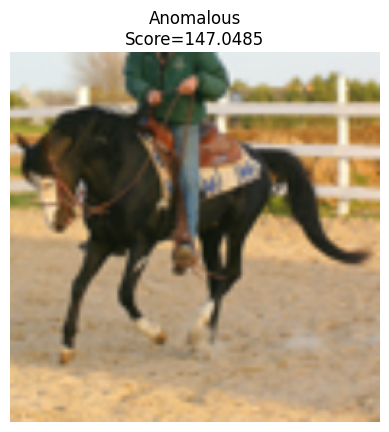

In [24]:
scores = np.array(scores)
labels = np.array(labels)

idx_norm = np.where(labels == 0)[0][0]
idx_anom = np.where(labels == 1)[0][0]

def show(idx, title):
    img = test_set[idx][0].permute(1,2,0)
    plt.imshow(img)
    plt.title(f"{title}\nScore={scores[idx]:.4f}")
    plt.axis("off")
    plt.show()

show(idx_norm, "Normal")
show(idx_anom, "Anomalous")
